## Import Packages

In [51]:

import pandas as pd 
import numpy as np
from keras.models import Sequential
from keras.layers import Activation,Dense,Dropout
from sklearn.preprocessing import LabelBinarizer
import sklearn.datasets as skds
import matplotlib as plt
from pathlib import Path
from keras.preprocessing.text import Tokenizer

## Data Path Access

In [52]:
dataset_path = '/home/dipak/Artificial-Intelligence/RNN/BbcNewsSummaries/'
file_path = skds.load_files(dataset_path,load_content=False)
file_path

{'filenames': array(['/home/dipak/Artificial-Intelligence/RNN/BbcNewsSummaries/business/385.txt',
        '/home/dipak/Artificial-Intelligence/RNN/BbcNewsSummaries/tech/160.txt',
        '/home/dipak/Artificial-Intelligence/RNN/BbcNewsSummaries/politics/090.txt',
        ...,
        '/home/dipak/Artificial-Intelligence/RNN/BbcNewsSummaries/entertainment/254.txt',
        '/home/dipak/Artificial-Intelligence/RNN/BbcNewsSummaries/entertainment/326.txt',
        '/home/dipak/Artificial-Intelligence/RNN/BbcNewsSummaries/sport/341.txt'],
       dtype='<U78'),
 'target_names': ['business', 'entertainment', 'politics', 'sport', 'tech'],
 'target': array([0, 4, 2, ..., 1, 1, 3]),
 'DESCR': None}

## Creating the CSV File Strucutre

In [53]:
file_label_index = file_path.target
file_label_name = file_path.target_names
labelled_files = file_path.filenames
i = 0
data_tag = ['filename','category','news']
data_list = []
for file in labelled_files:
    data_list.append((file,file_label_name[file_label_index[i]],Path(file).read_text()))
    i+=1
print(file_label_name)

['business', 'entertainment', 'politics', 'sport', 'tech']


In [54]:
df = pd.DataFrame.from_records(data_list,columns=data_tag)
df.head(5)

,filename,category,news
0,/home/dipak/Artificial-Intelligence/RNN/BbcNew...,business,"""After years of a sagging stock price and a se..."
1,/home/dipak/Artificial-Intelligence/RNN/BbcNew...,tech,Record numbers of Warcraft fans are settling i...
2,/home/dipak/Artificial-Intelligence/RNN/BbcNew...,politics,Climate change could be completely out of cont...
3,/home/dipak/Artificial-Intelligence/RNN/BbcNew...,sport,The 31-year-old was third behind Hayley Yellin...
4,/home/dipak/Artificial-Intelligence/RNN/BbcNew...,politics,Mr Flight says he will not stand down as a can...


## Train Test Split

In [61]:
total_data_size = len(df)
total_data_size

2225

In [62]:
train_data_size = int(total_data_size * 0.8)
test_data_size = int(total_data_size * 0.2)
print(train_data_size,test_data_size)

1780 445


In [64]:
train_data_category = df['category'][:train_data_size]
train_data_text = df['news'][:train_data_size]
test_data_category = df['category'][train_data_size:]
test_data_text = df['news'][train_data_size:]

print("Train Data")
print("================================")
print(train_data_text)
print("================================")
print("Test Data")
print("================================")
print(test_data_text)

Train Data
0       "After years of a sagging stock price and a se...
1       Record numbers of Warcraft fans are settling i...
2       Climate change could be completely out of cont...
3       The 31-year-old was third behind Hayley Yellin...
4       Mr Flight says he will not stand down as a can...
                              ...                        
1775    Coyne (Burnley), Jones (Wolves), Roberts (Wrex...
1776    Three senior executives of Ireland's state-own...
1777    Last year's Janet Jackson 'wardrobe malfunctio...
1778    Mr Wong has been blind from the age of seven a...
1779    Mr Cable said 40% of all pensioners were now p...
Name: news, Length: 1780, dtype: object
Test Data
1780    Rod Eddington, BA's chief executive, said the ...
1781    The Commission's controversial 2002 ruling gav...
1782    The Aviator has been tipped by UK bookmakers a...
1783    "The focus will be on job creation and economi...
1784    Malcolm Glazer has made a fresh approach to bu...
           

In [65]:
vocab_size = 20000
tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(train_data_text)

# Matrix Representaion of Training Text Dataset based on TFIDF calculation
X_train = tokenizer.texts_to_matrix(train_data_text,mode='tfidf')
X_test = tokenizer.texts_to_matrix(test_data_text,mode='tfidf')

# Encoding of The Training Categories like politics,sport,tech ... into Label Binerizer Form

# More on Label Binarizers
# let dat = ['Apple','Apple','Ball','Cat','Cat']
# then
# Label Encoder = [0,0,2,1,1] where 0 is apple, 2 is ball and so on
#Where label binerizer represets the abouve in 3D array form as below
# [[1,0,0],[1,0,0],[0,0,1],[0,1,0],[0,1,0]] where each means apple,ball cat resp.

encoder = LabelBinarizer()
encoder.fit(train_data_category)

Y_train = encoder.transform(train_data_category)
Y_test = encoder.transform(test_data_category)


In [66]:
X_train

array([[0.        , 2.13884041, 1.50725288, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 2.22064717, 1.50725288, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 2.36002393, 1.21604213, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 2.22064717, 0.71821407, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 2.22064717, 2.4404162 , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 2.52752415, 1.71387019, ..., 0.        , 0.        ,
        0.        ]])

In [67]:
X_test

array([[0.        , 2.04609556, 2.21169825, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 2.36002393, 2.11579412, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 2.22064717, 1.71387019, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 2.22064717, 2.00508094, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 2.77525439, 1.50725288, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.4576009 , 1.50725288, ..., 0.        , 0.        ,
        0.        ]])

In [68]:
Y_train

array([[1, 0, 0, 0, 0],
       [0, 0, 0, 0, 1],
       [0, 0, 1, 0, 0],
       ...,
       [0, 1, 0, 0, 0],
       [0, 0, 0, 0, 1],
       [0, 0, 1, 0, 0]])

In [69]:
Y_test

array([[1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [0, 1, 0, 0, 0],
       ...,
       [0, 1, 0, 0, 0],
       [0, 1, 0, 0, 0],
       [0, 0, 0, 1, 0]])

In [70]:
model = Sequential()
model.add(Dense(512,input_shape = (vocab_size,)))
model.add(Activation('relu'))
model.add(Dropout(0.25))

model.add(Dense(256))
model.add(Activation('relu'))
model.add(Dropout(0.25))

model.add(Dense(len(news_categories)))
model.add(Activation('softmax'))

model.summary()

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_12 (Dense)             (None, 512)               10240512  
_________________________________________________________________
activation_12 (Activation)   (None, 512)               0         
_________________________________________________________________
dropout_8 (Dropout)          (None, 512)               0         
_________________________________________________________________
dense_13 (Dense)             (None, 256)               131328    
_________________________________________________________________
activation_13 (Activation)   (None, 256)               0         
_________________________________________________________________
dropout_9 (Dropout)          (None, 256)               0         
_________________________________________________________________
dense_14 (Dense)             (None, 5)                

In [71]:
model.compile(optimizer='adam',loss='categorical_crossentropy',
             metrics=['accuracy'])


In [72]:
batch_size = 100
history = model.fit(X_train,Y_train,validation_data=(X_test,Y_test),epochs=20,batch_size=batch_size,validation_split=None)

Epoch 1/20
18/18 [==============================] - 2s 107ms/step - loss: 0.6501 - accuracy: 0.7831 - val_loss: 0.1264 - val_accuracy: 0.9640
Epoch 2/20
18/18 [==============================] - 2s 90ms/step - loss: 0.0130 - accuracy: 0.9978 - val_loss: 0.1362 - val_accuracy: 0.9685
Epoch 3/20
18/18 [==============================] - 2s 88ms/step - loss: 0.0014 - accuracy: 0.9994 - val_loss: 0.1296 - val_accuracy: 0.9640
Epoch 4/20
18/18 [==============================] - 2s 87ms/step - loss: 5.4447e-05 - accuracy: 1.0000 - val_loss: 0.1291 - val_accuracy: 0.9775
Epoch 5/20
18/18 [==============================] - 2s 88ms/step - loss: 3.9958e-05 - accuracy: 1.0000 - val_loss: 0.1322 - val_accuracy: 0.9775
Epoch 6/20
18/18 [==============================] - 2s 87ms/step - loss: 3.0040e-05 - accuracy: 1.0000 - val_loss: 0.1318 - val_accuracy: 0.9753
Epoch 7/20
18/18 [==============================] - 2s 89ms/step - loss: 2.3917e-05 - accuracy: 1.0000 - val_loss: 0.1311 - val_accuracy: 0.9

Text(0.5, 1.0, 'Loss Vs Validation Loss')

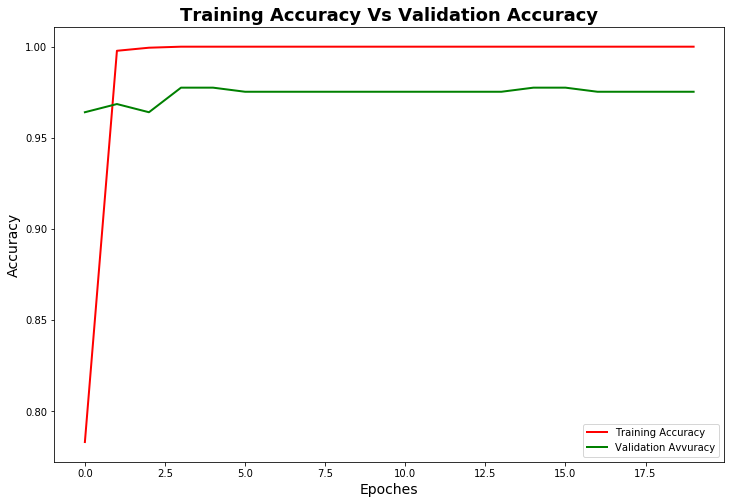

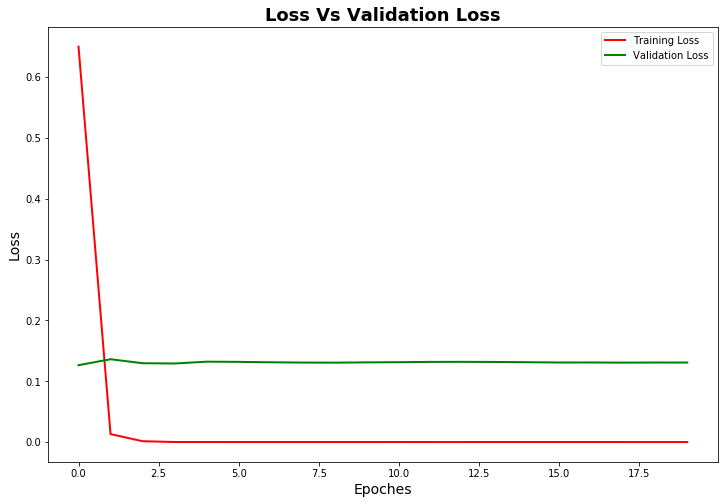

In [73]:
import matplotlib.pyplot as plt
plt.figure(figsize=[12,8])
plt.plot(history.history['accuracy'],'r',linewidth = 2.0)
plt.plot(history.history['val_accuracy'],'g',linewidth = 2.0)
plt.legend(['Training Accuracy','Validation Avvuracy'])
plt.xlabel("Epoches",fontsize=14)
plt.ylabel("Accuracy",fontsize=14)
plt.title("Training Accuracy Vs Validation Accuracy",fontweight = 'bold',fontsize=18)

plt.figure(figsize=[12,8])
plt.plot(history.history['loss'],'r',linewidth=2.0)
plt.plot(history.history['val_loss'],'g',linewidth = 2.0)
plt.legend(['Training Loss','Validation Loss'])
plt.xlabel("Epoches",fontsize=14)
plt.ylabel("Loss",fontsize=14)
plt.title("Loss Vs Validation Loss",fontweight = 'bold',fontsize=18)

In [74]:
from sklearn.metrics import confusion_matrix,plot_confusion_matrix,classification_report
y_pred = model.predict_classes(X_test,verbose=0)
y_pred2 = np.argmax(Y_test,axis = -1)
reasult = confusion_matrix(y_pred2,y_pred)
print("=======================================")
print("Confusion Matrix")
print("=======================================")
print(reasult)
print("=======================================")
print("Classificaiton Report")
print("=======================================")
print(classification_report(y_pred2,y_pred,target_names=news_categories))

Instructions for updating:
Please use instead:* `np.argmax(model.predict(x), axis=-1)`,   if your model does multi-class classification   (e.g. if it uses a `softmax` last-layer activation).* `(model.predict(x) > 0.5).astype("int32")`,   if your model does binary classification   (e.g. if it uses a `sigmoid` last-layer activation).


/home/dipak/anaconda3/lib/python3.7/importlib/_bootstrap.py:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 192 from C header, got 216 from PyObject
  return f(*args, **kwds)


Confusion Matrix
[[ 91   0   3   0   1]
 [  0  77   1   1   0]
 [  1   1  77   1   1]
 [  0   0   0 104   0]
 [  0   0   1   0  85]]
Classificaiton Report
               precision    recall  f1-score   support

     business       0.99      0.96      0.97        95
entertainment       0.99      0.97      0.98        79
     politics       0.94      0.95      0.94        81
        sport       0.98      1.00      0.99       104
         tech       0.98      0.99      0.98        86

     accuracy                           0.98       445
    macro avg       0.97      0.97      0.97       445
 weighted avg       0.98      0.98      0.98       445



/home/dipak/anaconda3/lib/python3.7/importlib/_bootstrap.py:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 192 from C header, got 216 from PyObject
  return f(*args, **kwds)


Text(0.5, 1, 'Confusion Matrix Visualization with Seaborn')

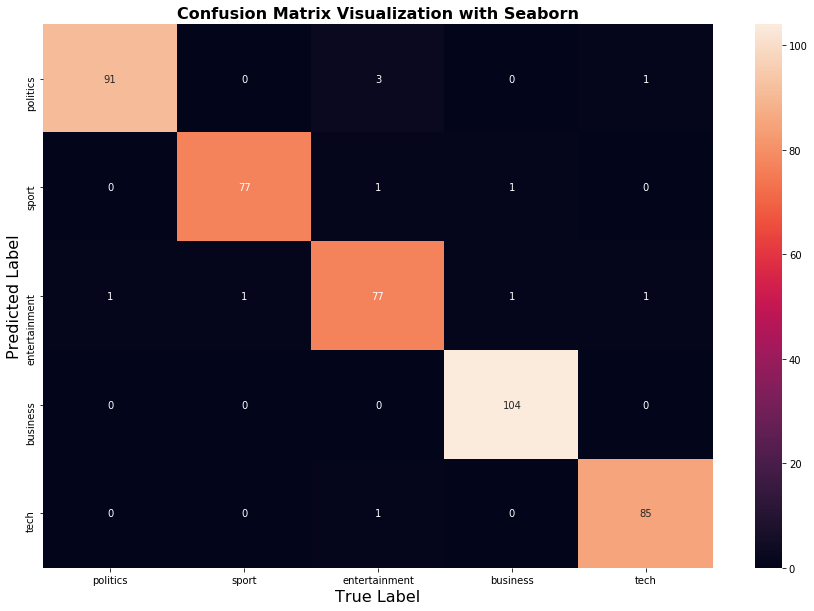

In [75]:
import seaborn as sns
figure_size = plt.figure(figsize=(15,10))
x_tick_label = ['politics','sport','entertainment','business','tech']
y_tick_label = ['politics','sport','entertainment','business','tech']
heatmap = sns.heatmap(reasult,annot=True,fmt='d',xticklabels=x_tick_label,yticklabels=y_tick_label)
plt.xlabel("True Label",fontsize = 16)
plt.ylabel("Predicted Label",fontsize = 16)
plt.title("Confusion Matrix Visualization with Seaborn",fontsize = 16,fontweight = 'bold')

In [76]:
text_labels = encoder.classes_
for i in range(10):
  prediction = model.predict(np.array([X_test[i]]))
  predicted_class = text_labels[np.argmax(prediction[0])]
  print(test_data_text.iloc[i])
  print('Actual Category =',test_data_category.iloc[i])
  print('Predicted Category =',predicted_class)

Rod Eddington, BA's chief executive, said the results were "respectable" in a third quarter when fuel costs rose by £106m or 47.3%.To help offset the increased price of aviation fuel, BA last year introduced a fuel surcharge for passengers.BA had previously forecast a 2% to 3% rise in full-year revenue."It is quite good on the revenue side and it shows the impact of fuel surcharges and a positive cargo development, however, operating margins down and cost impact of fuel are very strong," he said.Yet aviation analyst Mike Powell of Dresdner Kleinwort Wasserstein says BA's estimated annual surcharge revenues - £160m - will still be way short of its additional fuel costs - a predicted extra £250m."For the year to March 2005, the total revenue outlook is slightly better than previous guidance with a 3% to 3.5% improvement anticipated," BA chairman Martin Broughton said.Looking ahead to its full year results to March 2005, BA warned that yields - average revenues per passenger - were expect

In [79]:
model.save("BBC_Folder_News_Classifier.h5")

In [80]:
import pickle
with open('tokenizer.pickle','wb') as myfile:
  pickle.dump(tokenizer,myfile,protocol=pickle.HIGHEST_PROTOCOL)

In [81]:
from keras.models import load_model
model = load_model('BBC_Folder_News_Classifier.h5')
tokenizer = Tokenizer()
with open('tokenizer.pickle','rb') as myfile:
  tokenizer = pickle.load(myfile)

labels = encoder.classes_
labels

array(['business', 'entertainment', 'politics', 'sport', 'tech'],
      dtype='<U13')

In [82]:
test_files = "bbctest_business/001.txt"
b = open(test_files,'r')
data = b.read()
data_series = pd.Series(data)
data_tokenized = tokenizer.texts_to_matrix(data_series,mode='tfidf')
prediction = model.predict(data_tokenized)
predicted_class = text_labels[np.argmax(prediction[0])]
print('My News =',data)
print('Predicted Category =',predicted_class)
print('My category = ',labels)
print('Prediction Value = ',prediction)

My News = TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn.For the full-year, TimeWarner posted a profit of $3.36bn, up 27% from its 2003 performance, while revenues grew 6.4% to $42.09bn.Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.However, the company said AOL's underlying profit before exceptional items rose 8% on the back of stronger internet advertising revenues.Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.For 2005, TimeWarner is projecting operating earnings growth of around 5%, and also expects higher revenue and wider profit margins.It lost 464,000 subscribers in the fourth quarter profits were lower than in the preceding three quarters.Time Warner's fourth quarter profits were slightly better than analysts' expectations.
Predicted Category = business
My category =  ['business' 'entertainment' 'politics' 'spor